<a href="https://colab.research.google.com/github/fujisawatet/Spotify_data/blob/main/%E3%82%B8%E3%83%A3%E3%83%B3%E3%83%AB%E5%88%A5_2020_2021_SHAP%E3%82%AF%E3%83%A9%E3%82%B9%E3%82%BF%E3%83%AA%E3%83%B3%E3%82%B0_hip_hop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#7.21 必要なコードだけに整理

In [ ]:
#@title import
from urllib.request import urlretrieve
import os
from zipfile import ZipFile

import pandas as pd

In [ ]:
boxurl = "https://tus.box.com/shared/static/491ie3a5kdgg7hfajivmwlou6zq2fnzj.zip"
filename = "Kaggle_Spotify_1Million_Tracks.zip"

In [ ]:
%%time
urlretrieve(boxurl, filename)

CPU times: user 217 ms, sys: 175 ms, total: 393 ms
Wall time: 1.54 s


('Kaggle_Spotify_1Million_Tracks.zip',
 <http.client.HTTPMessage at 0x7b1281007df0>)

In [ ]:
ZipFile(filename).extractall()

In [ ]:
%pip install japanize-matplotlib --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 39.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import japanize_matplotlib
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance

plt.rcParams['font.family'] = 'IPAexGothic'
plt.rcParams['axes.unicode_minus'] = False

print(f"shap バージョン: {shap.__version__}")

shap バージョン: 0.52.0


In [ ]:
df = pd.read_csv("/content/spotify_data.csv", index_col=0)
print(f"データ形状: {df.shape}")

df_clean = df.dropna(subset=['popularity']).copy()

データ形状: (1159764, 19)


# Step1 ;2020年単体データ絞り込み・SHAP値計算

In [ ]:
# genre_enc を除いた15特徴量 + gb2 モデルの再定義
FEATURE_COLS_V2 = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'duration_ms', 'key', 'mode', 'time_signature',
    #'artist_freq'
]

print("HistGradientBoosting (no genre_enc) training...")
gb2 = HistGradientBoostingRegressor(
        max_iter=100, learning_rate=0.05, max_depth=3,
        min_samples_leaf=50, l2_regularization=1.0, random_state=42
    )
#HistGradientBoostingRegressor(
#    max_iter=300, learning_rate=0.05, max_depth=8,
#    min_samples_leaf=20, l2_regularization=0.1, random_state=42
#)

HistGradientBoosting (no genre_enc) training...


In [ ]:
df_clean['genre'].value_counts().sort_values(ascending=False).head(15)

,count
genre,
black-metal,21852
gospel,21621
ambient,21389
acoustic,21097
alt-rock,20918
emo,20845
indian,20583
k-pop,20004
new-age,19911


In [ ]:
#@title filtering 2020/genre sampling
TARGET_YEAR = 2020
TARGET_GENRE = 'hip-hop'#@param['black-metal','hip-hop','k-pop']
TEST_YEAR = 2021
df_2020 = df_clean[df_clean['year'] == TARGET_YEAR].copy()
df_2021 = df_clean[df_clean['year'] == TEST_YEAR].copy()
df_2020 = df_2020[df_2020['genre']==TARGET_GENRE]
df_2021 = df_2021[df_2021['genre']==TARGET_GENRE]

print(f"filter: year == {TARGET_YEAR}")
print(f"records: {len(df_2020):,} / {len(df_2020)/len(df_clean)*100:.1f}% of all data")
print(f"popularity: mean={df_2020['popularity'].mean():.1f}, "
      f"median={df_2020['popularity'].median():.1f}, "
      f"std={df_2020['popularity'].std():.2f}")
print(f"\ntop 10 genres:")
print(df_2020['genre'].value_counts().head(10).to_string())

N_MAX3 = 10000
rng4 = np.random.default_rng(42)
if len(df_2020) > N_MAX3:
    idx_a = rng4.choice(len(df_2020), size=N_MAX3, replace=False)
    df_2020_sample = df_2020.iloc[idx_a].reset_index(drop=True)
    print(f"\nsampled: {len(df_2020):,} -> {N_MAX3:,}")
else:
    df_2020_sample = df_2020.reset_index(drop=True)
    print(f"\nall records used: {len(df_2020_sample):,}")

X_2020_sample = df_2020_sample[FEATURE_COLS_V2]


filter: year == 2020
records: 854 / 0.1% of all data
popularity: mean=56.6, median=55.0, std=7.13

top 10 genres:
genre
hip-hop    854

all records used: 854


In [ ]:
X2_train = df_2020[FEATURE_COLS_V2]
X2_test  = df_2021[FEATURE_COLS_V2]
y_train = df_2020['popularity']
y_test = df_2021['popularity']

In [ ]:
%%time
gb2.fit(X2_train, y_train)
gb2_pred = gb2.predict(X2_test)
print(f"done / MAE={mean_absolute_error(y_test, gb2_pred):.4f}, R2={r2_score(y_test, gb2_pred):.4f}")


done / MAE=6.2595, R2=0.0084
CPU times: user 87.6 ms, sys: 2.93 ms, total: 90.5 ms
Wall time: 94.5 ms


In [ ]:
%%time
print("building SHAP Explainer (no genre_enc)...")
rng = np.random.default_rng(42)
# 背景データは最大100件（hip-hop 2020年は854曲しかなく900件は取れない。SHAPは内部で100件に間引くので結果はほぼ同じ）
bg_idx = rng.choice(len(X2_train), size=min(100, len(X2_train)), replace=False)
X2_bg = X2_train[FEATURE_COLS_V2].iloc[bg_idx]
explainer_gb2 = shap.Explainer(gb2, X2_bg)
print("done")

# 確認: 基準値が学習データの人気度平均に近ければ、今のジャンルのモデルで作られている
base_val = float(np.ravel(explainer_gb2.expected_value)[0])
print(f"expected_value = {base_val:.2f} / {TARGET_GENRE} {TARGET_YEAR} popularity mean = {y_train.mean():.2f}")

In [ ]:
%%time
#time 19sec
print("computing SHAP values...")
shap_values_v3 = explainer_gb2(X2_test, check_additivity=False)
shap_matrix_v3 = shap_values_v3.values
print(f"done / shap_matrix_v3 shape: {shap_matrix_v3.shape}")

computing SHAP values...


 99%|===================| 844/850 [00:15<00:00]       

done / shap_matrix_v3 shape: (850, 13)
CPU times: user 14.8 s, sys: 43.4 ms, total: 14.9 s
Wall time: 14.9 s


#21年でのテスト評価

#SHAP Plots

In [ ]:
# shap_values_v3 はこの時点で2021年の曲のSHAP値なので、特徴量も2021年（X2_test）を渡す
shap.summary_plot(shap_values_v3, X2_test, plot_type="bar", show=False)

In [ ]:
shap.initjs()
shap.force_plot(explainer_gb2.expected_value, shap_values_v3.values[0], X2_test.iloc[0])

#Step 2: クラスタ数の探索

In [ ]:
#18sec
%%time
TARGET_YEAR = 2020
#df_2020 = df_clean[df_clean['year'] == TARGET_YEAR].copy()

print(f"filter: year == {TARGET_YEAR}")
print(f"records: {len(df_2020):,} / {len(df_2020)/len(df_clean)*100:.1f}% of all data")
print(f"popularity: mean={df_2020['popularity'].mean():.1f}, "
      f"median={df_2020['popularity'].median():.1f}, "
      f"std={df_2020['popularity'].std():.2f}")
print(f"\ntop 10 genres:")
print(df_2020['genre'].value_counts().head(10).to_string())

N_MAX3 = 10000
rng4 = np.random.default_rng(42)
if len(df_2020) > N_MAX3:
    idx_a = rng4.choice(len(df_2020), size=N_MAX3, replace=False)
    df_2020_sample = df_2020.iloc[idx_a].reset_index(drop=True)
    print(f"\nsampled: {len(df_2020):,} -> {N_MAX3:,}")
else:
    df_2020_sample = df_2020.reset_index(drop=True)
    print(f"\nall records used: {len(df_2020_sample):,}")

X_2020_sample = df_2020_sample[FEATURE_COLS_V2]

print("computing SHAP values...")
shap_values_v3 = explainer_gb2(X_2020_sample, check_additivity=False)
shap_matrix_v3 = shap_values_v3.values
print(f"done / shap_matrix_v3 shape: {shap_matrix_v3.shape}")

filter: year == 2020
records: 854 / 0.1% of all data
popularity: mean=56.6, median=55.0, std=7.13

top 10 genres:
genre
hip-hop    854

all records used: 854
computing SHAP values...


100%|===================| 852/854 [00:16<00:00]       

done / shap_matrix_v3 shape: (854, 13)
CPU times: user 15.4 s, sys: 35 ms, total: 15.4 s
Wall time: 15.6 s


standardized / shape: (854, 13)
  k=2: inertia=10003.4, silhouette=0.099
  k=3: inertia=9261.2, silhouette=0.095
  k=4: inertia=8596.3, silhouette=0.107
  k=5: inertia=8179.6, silhouette=0.092
  k=6: inertia=7708.7, silhouette=0.114
  k=7: inertia=7359.2, silhouette=0.115
  k=8: inertia=7029.5, silhouette=0.112
  k=9: inertia=6829.8, silhouette=0.104
  k=10: inertia=6606.7, silhouette=0.106


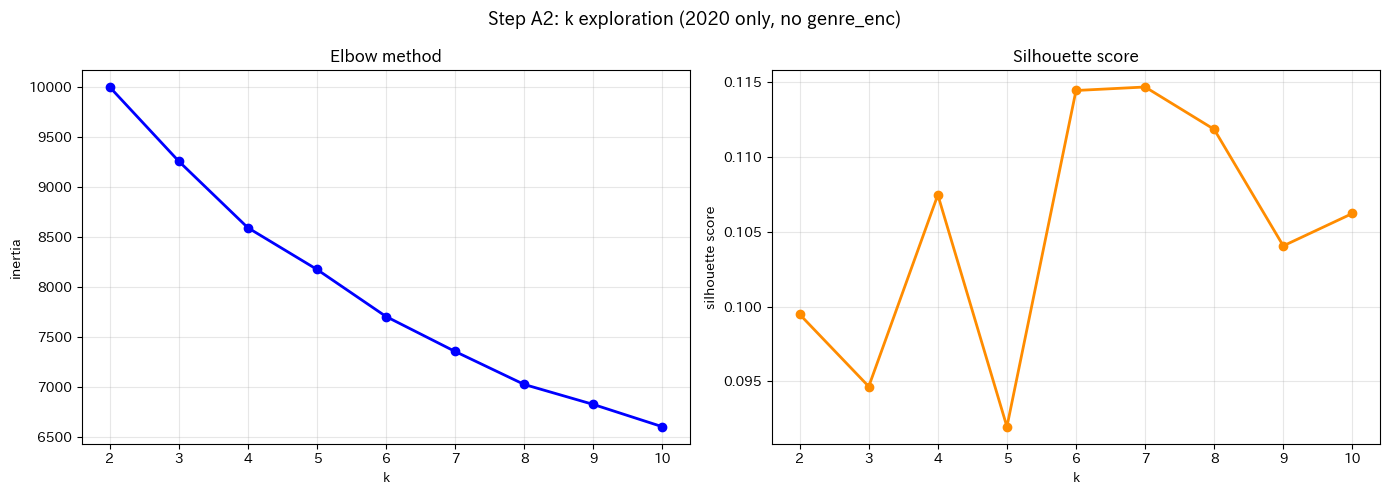

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scaler_v3 = StandardScaler()
shap_scaled_v3 = scaler_v3.fit_transform(shap_matrix_v3)
print(f"standardized / shape: {shap_scaled_v3.shape}")

inertias_v3 = []
silhouettes_v3 = []
K_range_v3 = range(2, 11)

for k in K_range_v3:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(shap_scaled_v3)
    inertias_v3.append(km.inertia_)
    sil = silhouette_score(shap_scaled_v3, labels_k,
                           sample_size=min(2000, len(shap_scaled_v3)), random_state=42)
    silhouettes_v3.append(sil)
    print(f"  k={k}: inertia={km.inertia_:.1f}, silhouette={sil:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Step A2: k exploration (2020 only, no genre_enc)", fontsize=13, fontweight='bold')

axes[0].plot(list(K_range_v3), inertias_v3, 'b-o', linewidth=2)
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertia")
axes[0].set_title("Elbow method")
axes[0].grid(alpha=0.3)

axes[1].plot(list(K_range_v3), silhouettes_v3, 'o-', color='darkorange', linewidth=2)
axes[1].set_xlabel("k")
axes[1].set_ylabel("silhouette score")
axes[1].set_title("Silhouette score")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('phase3_2020_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

#Step3: クラスタリング実行（k=7）

In [ ]:
CHOSEN_K_V3 = 7  # silhouette score 最高値（0.126）

km_v3 = KMeans(n_clusters=CHOSEN_K_V3, random_state=42, n_init=10)
cluster_labels_v3 = km_v3.fit_predict(shap_scaled_v3)
df_2020['cluster_v3'] = cluster_labels_v3

chosen_sil_v3 = silhouettes_v3[CHOSEN_K_V3 - 2]
print(f"clustering done / k={CHOSEN_K_V3} (silhouette={chosen_sil_v3:.3f})")
print(f"\ncluster counts:")
print(df_2020['cluster_v3'].value_counts().sort_index().to_string())

print(f"\ncluster overview:")
for k in range(CHOSEN_K_V3):
    mask = df_2020['cluster_v3'] == k
    df_k = df_2020[mask]
    top3_g = df_k['genre'].value_counts().head(3).index.tolist()
    print(f"  cluster {k}: {len(df_k):,} tracks / pop mean={df_k['popularity'].mean():.1f} / {', '.join(top3_g)}")

clustering done / k=7 (silhouette=0.115)

cluster counts:
cluster_v3
0    126
1    233
2     64
3    207
4     64
5    132
6     28

cluster overview:
  cluster 0: 126 tracks / pop mean=56.5 / hip-hop
  cluster 1: 233 tracks / pop mean=57.1 / hip-hop
  cluster 2: 64 tracks / pop mean=58.4 / hip-hop
  cluster 3: 207 tracks / pop mean=55.9 / hip-hop
  cluster 4: 64 tracks / pop mean=58.4 / hip-hop
  cluster 5: 132 tracks / pop mean=55.4 / hip-hop
  cluster 6: 28 tracks / pop mean=55.8 / hip-hop


In [ ]:
#@title scalingした値を代入
df_2020_sample = df_2020.copy()
df_2020_sample[FEATURE_COLS_V2] = shap_scaled_v3
df_2020_sample

,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,cluster_v3
452805,21 Savage,Glock In My Lap,6pcywuOeGGWeOQzdUyti6k,84,2020,hip-hop,1.062370,0.676085,-0.270429,0.248287,0.903288,0.727077,1.150471,-1.779521,0.379908,-0.402828,-0.819878,-0.388880,-0.176518,3
452806,Brent Faiyaz,Clouded,2J6OF7CkpdQGSfm1wdclqn,80,2020,hip-hop,0.759074,-1.382712,-0.048351,-0.039502,-0.411277,-1.562427,4.824818,0.519672,0.943534,-0.094013,1.884639,0.444844,-2.092485,2
452807,21 Savage,Runnin,5SWnsxjhdcEDc7LJjq9UHk,80,2020,hip-hop,1.377687,0.001312,-1.979584,0.646314,0.756117,-0.541403,0.571092,0.323473,0.835981,0.789821,-0.479098,-0.482154,0.080574,4
452808,Playboi Carti,Sky,29TPjc8wxfz4XMn21O7VsZ,81,2020,hip-hop,0.348257,0.275246,0.011535,0.127374,-0.984383,-0.024207,-0.445324,1.467164,0.617033,0.308206,-0.173906,-0.233856,-0.029731,1
452809,"Tyler, The Creator",BEST INTEREST,3jHdKaLCkuNEkWcLVmQPCX,79,2020,hip-hop,-0.706004,0.293648,-0.615935,-0.594218,0.897895,-0.982557,0.110634,-2.751838,-1.036469,-0.937613,-0.181362,2.027471,-4.285166,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
453654,Zaia,VERY ALONE,1LCgehdvJ91SgSRuI7Ez90,49,2020,hip-hop,-0.432635,0.304176,0.005916,-0.756709,-0.590152,-2.214047,0.359806,-0.616334,-0.493366,-0.730055,-0.631032,0.349673,0.641436,3
453655,Toosii,Pain & Problems,1HldQ2TyklbzNOujUpl4bO,47,2020,hip-hop,0.323897,0.353953,-0.323310,-0.026888,-0.761865,-0.942082,1.957678,-0.264643,0.502161,-0.698056,-1.397498,-0.521072,-5.480698,6
453656,Kenny Mason,Hit,2CIktojfxYQEPqruYivUrO,46,2020,hip-hop,0.397649,1.498768,-0.204322,-0.617514,0.678541,-0.146784,-0.582194,0.337770,1.101687,0.552627,1.014068,0.570721,0.386139,1
453657,Russ,GUESS WHAT (feat. Rick Ross),40FUPlp2KJvdHY5ABnK100,50,2020,hip-hop,1.402417,-0.610362,0.557632,-1.509913,-0.157440,-1.286561,0.182550,-0.223789,1.092552,-0.370097,0.804373,0.219138,-0.121804,3


In [ ]:
df_2020['cluster_v3'].unique()

array([3, 2, 4, 1, 6, 0, 5], dtype=int32)

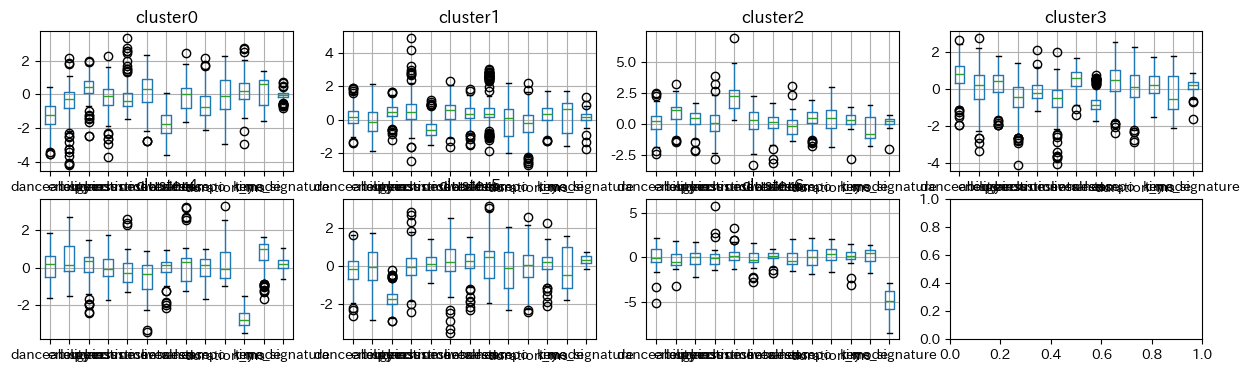

In [ ]:
fig, axes = plt.subplots(2,4, figsize=(15,4))
for ax,(i,df) in zip(axes.ravel(), df_2020_sample.groupby('cluster_v3')[FEATURE_COLS_V2]):
  df[FEATURE_COLS_V2].boxplot(ax=ax)
  ax.set_title(f'cluster{i}')
plt.show()

#Step4: 箱ひげ図

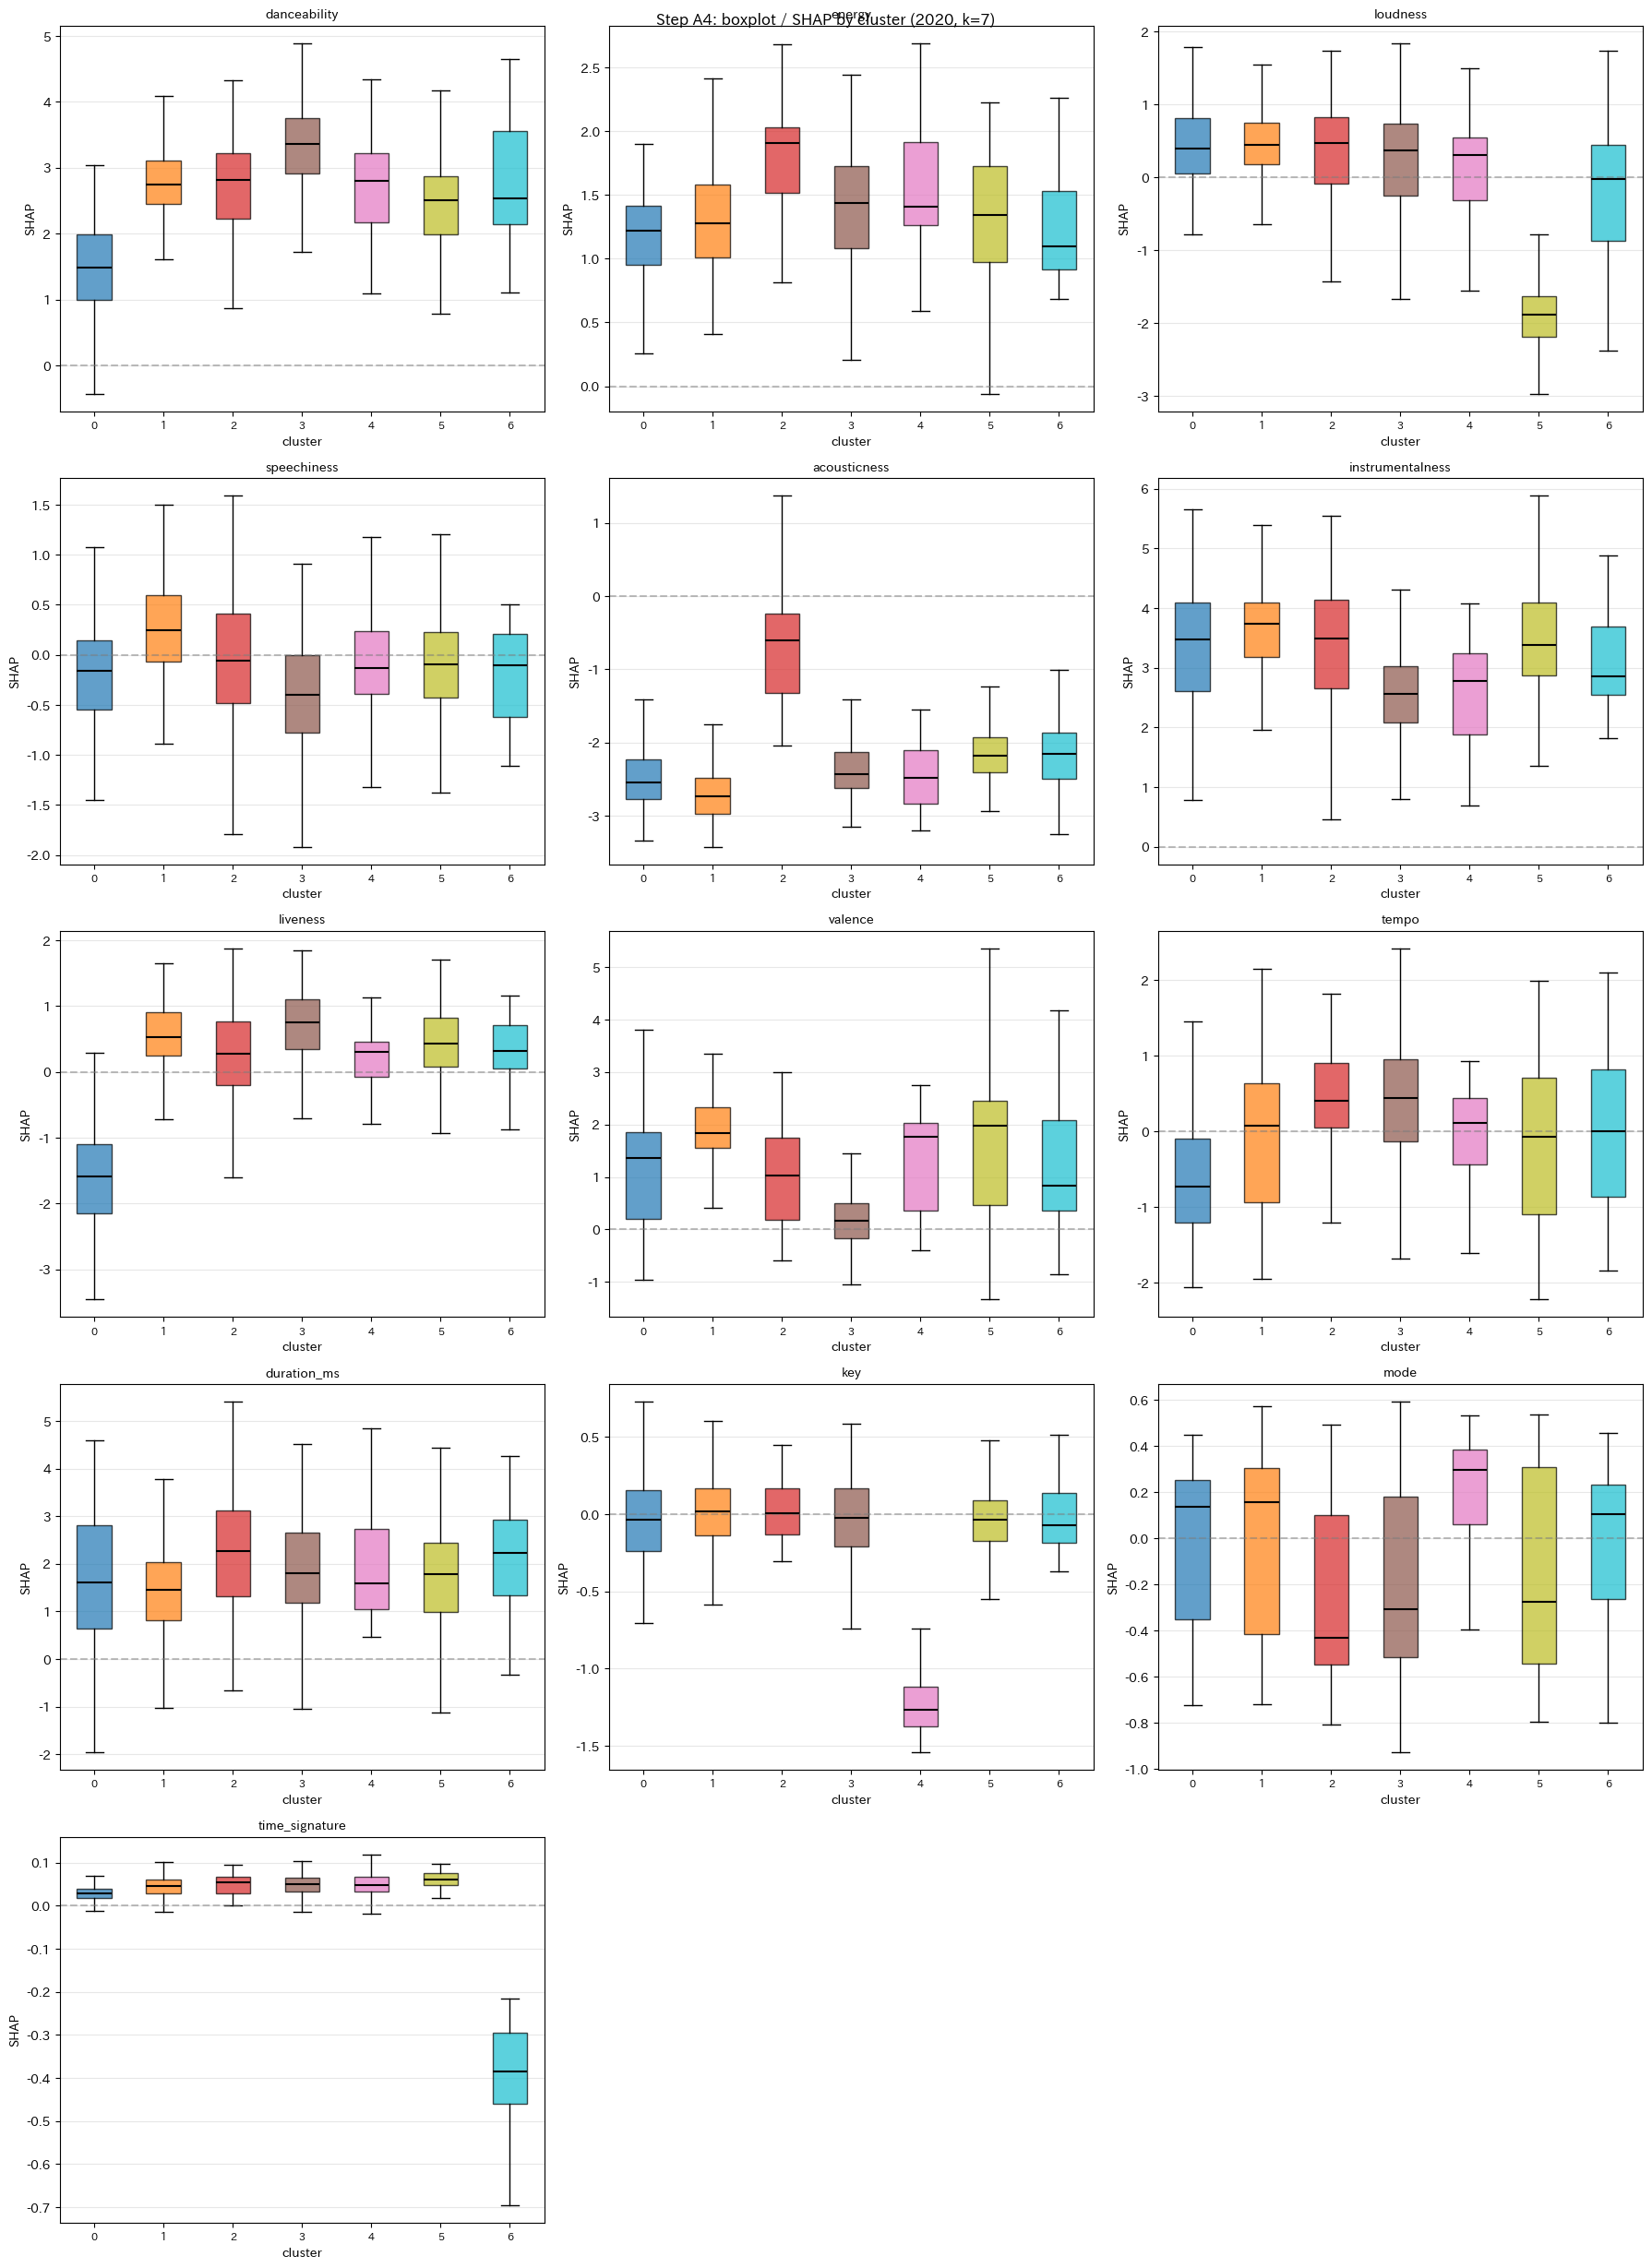

saved: phase3_2020_boxplot.png


In [ ]:
#@title plot features
n_cols = 3
n_rows = 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 25))
fig.suptitle("Step A4: boxplot / SHAP by cluster (2020, k=7)", fontsize=12, fontweight='bold')
colors = plt.cm.tab10(np.linspace(0, 1, CHOSEN_K_V3))
xlabels = [str(i) for i in range(CHOSEN_K_V3)]

for fi, fname in enumerate(FEATURE_COLS_V2):
    r = fi // n_cols
    c = fi % n_cols
    ax = axes[r, c]
    data = [shap_matrix_v3[cluster_labels_v3 == i, fi] for i in range(CHOSEN_K_V3)]
    bp = ax.boxplot(data, patch_artist=True, showfliers=False, medianprops=dict(color='black', linewidth=1.5))
    for patch, col in zip(bp['boxes'], colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.7)
    ax.set_title(fname, fontsize=10, fontweight='bold')
    ax.set_xlabel("cluster")
    ax.set_ylabel("SHAP")
    ax.set_xticks(range(1, CHOSEN_K_V3 + 1))
    ax.set_xticklabels(xlabels, fontsize=8)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.grid(axis='y', alpha=0.3)

for i in range(len(FEATURE_COLS_V2), n_rows * n_cols):
    axes[i // n_cols][i % n_cols].set_visible(False)

plt.tight_layout()
plt.savefig('phase3_2020_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved: phase3_2020_boxplot.png")

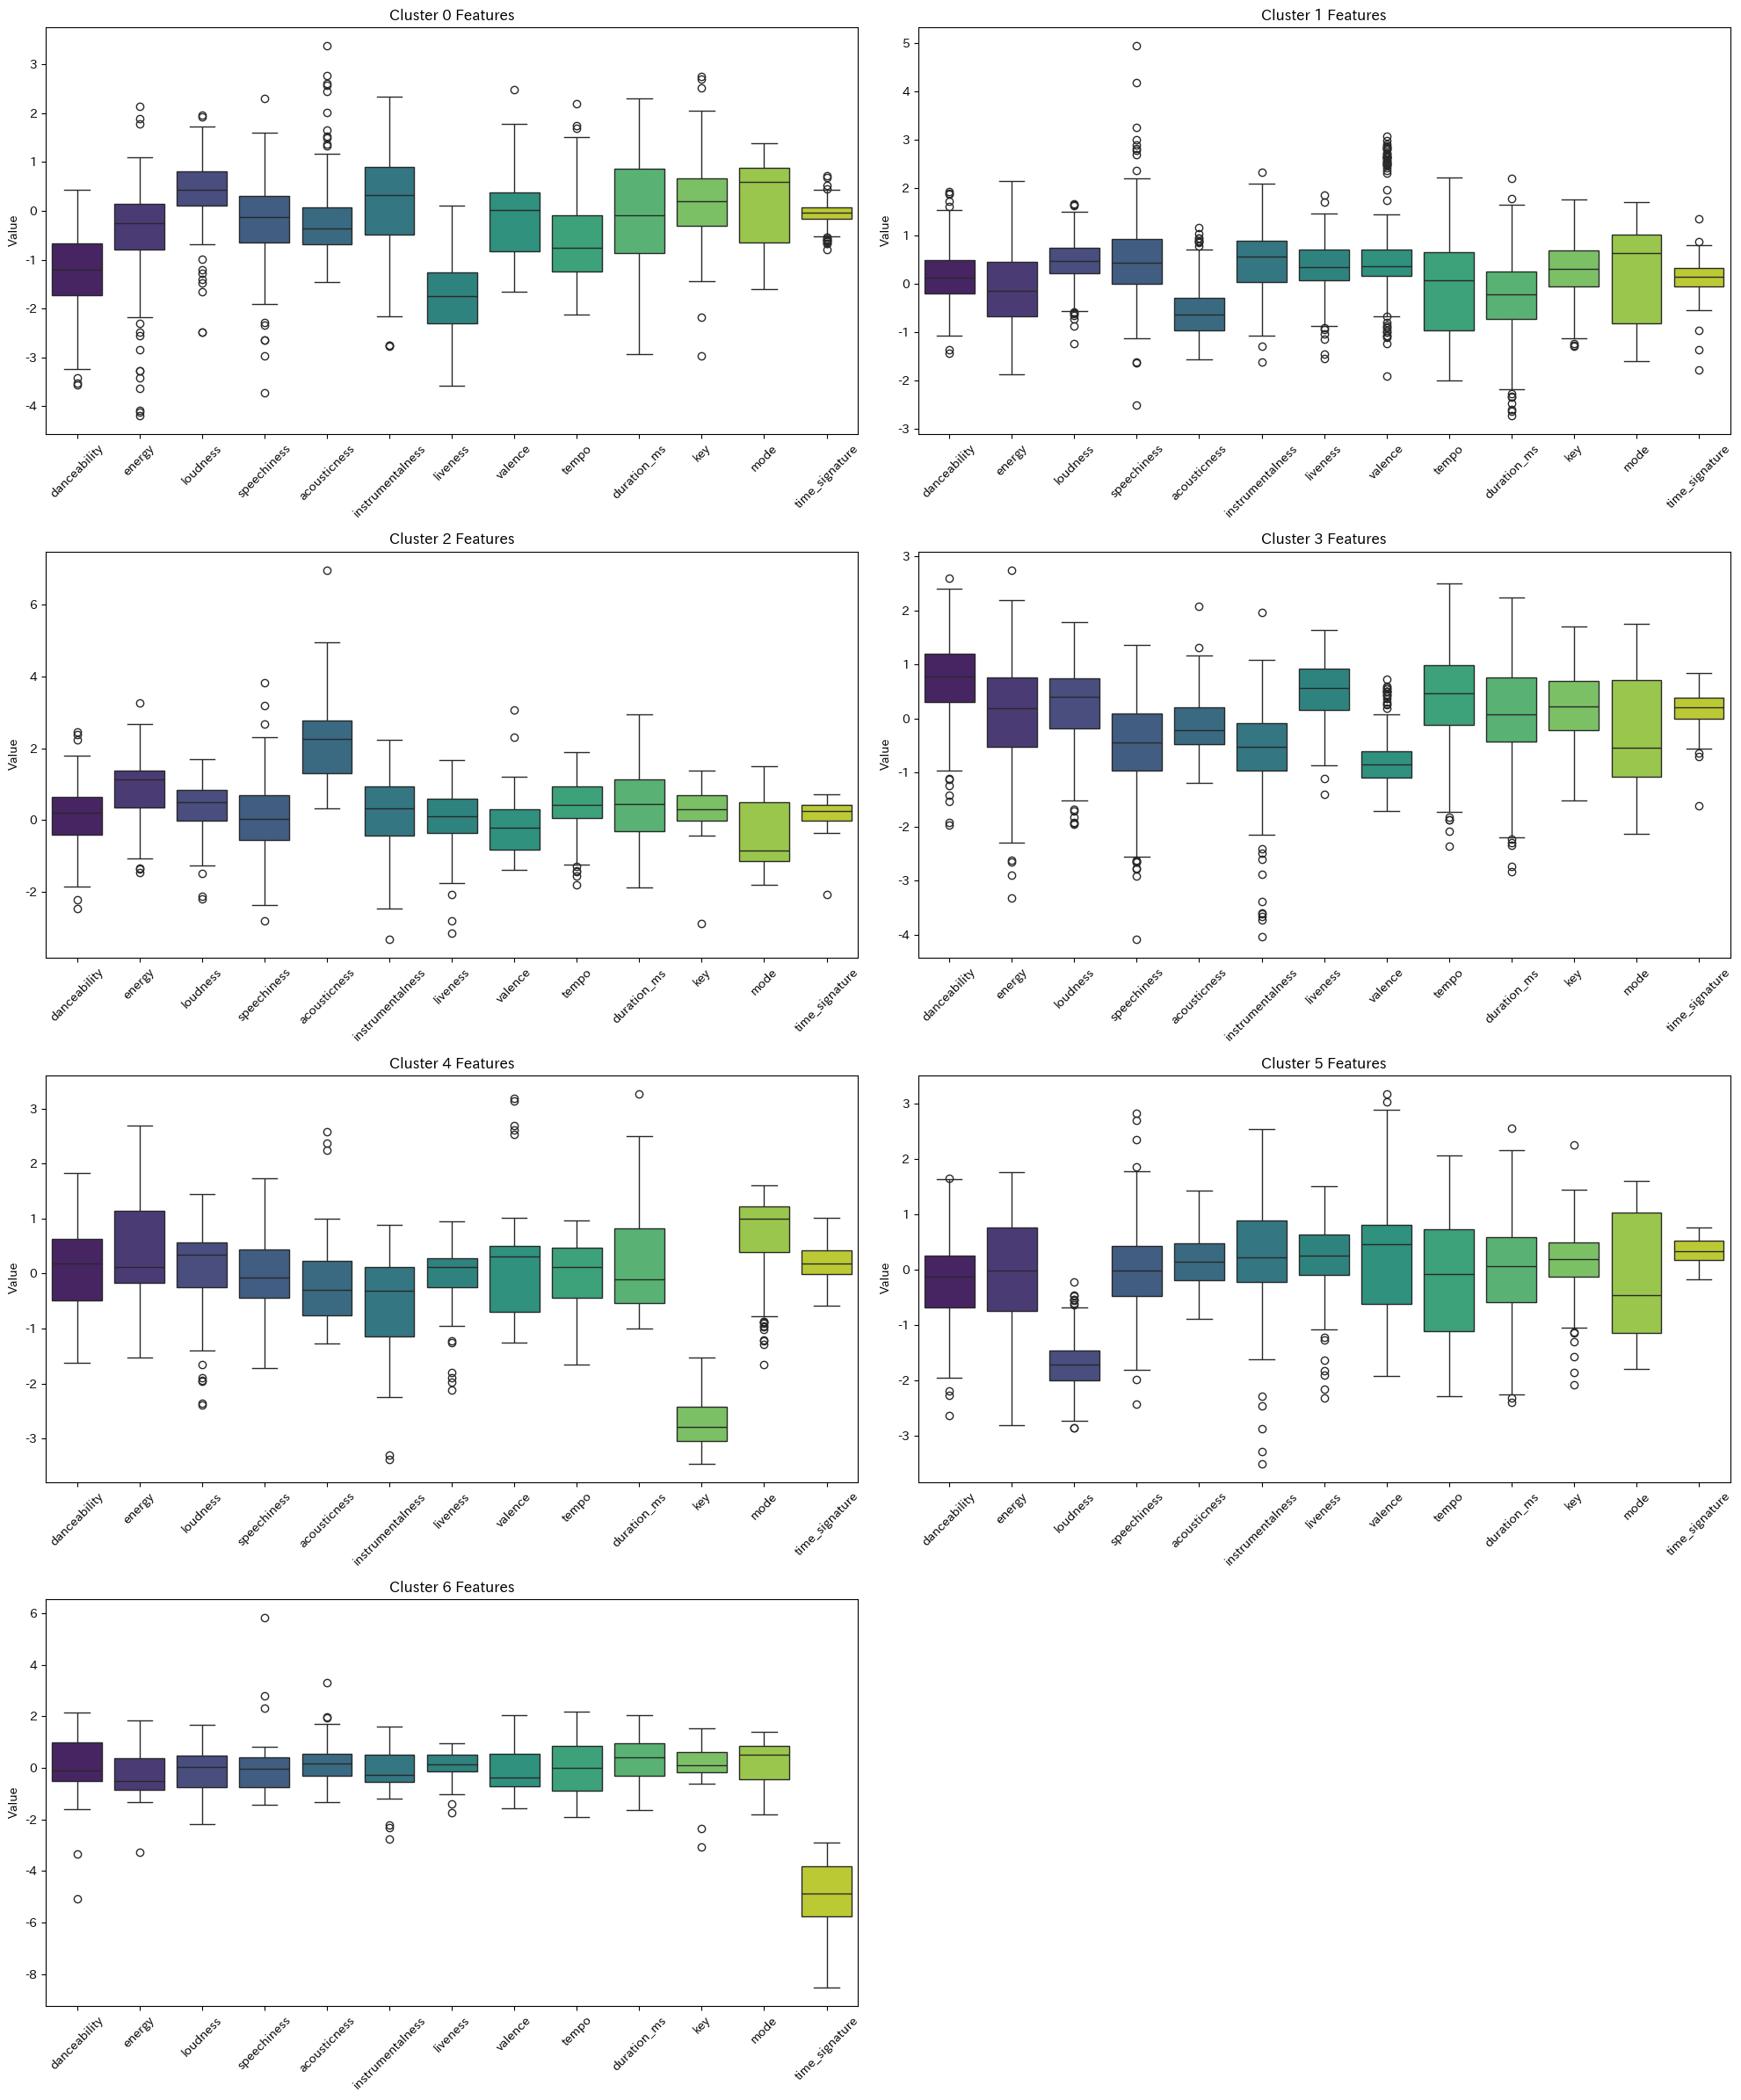

In [ ]:
#plot a box plot of all features for each cluster. each box plot should have all features in xticks and plot its value for one cluster
import matplotlib.pyplot as plt
import seaborn as sns
import math

n_clusters = df_2020_sample['cluster_v3'].nunique()
cols = 2
rows = math.ceil(n_clusters / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 6 * rows))
axes = axes.ravel()

# Melt the dataframe so we can easily plot features on the x-axis
df_melted = df_2020_sample.melt(id_vars=['cluster_v3'], value_vars=FEATURE_COLS_V2, var_name='Feature', value_name='Value')

clusters = sorted(df_2020_sample['cluster_v3'].unique())
for i, cluster_id in enumerate(clusters):
    cluster_data = df_melted[df_melted['cluster_v3'] == cluster_id]
    sns.boxplot(x='Feature', y='Value', data=cluster_data, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Cluster {cluster_id} Features')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
# まとめ出力（実行結果から自動で作る。ジャンルを変えてもそのまま使える）
print("=" * 70)
print(f"Summary: {TARGET_GENRE} / train {TARGET_YEAR} -> test {TEST_YEAR} / k={CHOSEN_K_V3}")
print("=" * 70)

print("\n[Data]")
print(f"  train {TARGET_YEAR}: {len(df_2020):,} tracks / test {TEST_YEAR}: {len(df_2021):,} tracks")
print(f"  popularity {TARGET_YEAR}: mean={df_2020['popularity'].mean():.1f}, std={df_2020['popularity'].std():.2f}")

print("\n[Model: gb2 (iter=100, depth=3, leaf=50, l2=1.0)]")
print(f"  test {TEST_YEAR}: MAE={mean_absolute_error(y_test, gb2_pred):.4f}, R2={r2_score(y_test, gb2_pred):.4f}")

print(f"\n[Clustering on SHAP values of {TARGET_YEAR} tracks]")
print(f"  k = {CHOSEN_K_V3} (silhouette = {chosen_sil_v3:.3f})")

labels_arr = df_2020['cluster_v3'].values
for k in range(CHOSEN_K_V3):
    d_k = df_2020[labels_arr == k]
    mean_shap = shap_matrix_v3[labels_arr == k].mean(axis=0)
    top_i = int(np.argmax(mean_shap))
    bot_i = int(np.argmin(mean_shap))
    line = f"  C{k}: {len(d_k):>4} tracks / pop={d_k['popularity'].mean():.1f}"
    line += f" / SHAP+ {FEATURE_COLS_V2[top_i]}({mean_shap[top_i]:+.2f})"
    line += f" / SHAP- {FEATURE_COLS_V2[bot_i]}({mean_shap[bot_i]:+.2f})"
    print(line)

print("\n" + "=" * 70)

#Step5: 各クラスタに分けられた曲のタイトル一覧

**打ち合わせメモ**: hip-hop の中で特徴によって違うから、タイトルなどを聞いて違いがわかるか / 各クラスタに分けられた曲のタイトルがわかるか

各クラスタについて次を表示する。

- **特徴量の傾向**: そのクラスタの曲が、ジャンル全体と比べてどの音楽的特徴が高い/低いか（標準化した値の平均）。聴くときに注目するポイントになる
- **代表曲**: クラスタの中心に最も近い曲。そのクラスタらしさが一番よく出ている曲
- **人気曲**: クラスタ内で popularity が高い曲。知っている曲が見つかりやすい
- **主なアーティスト**: 1人のアーティストの曲ばかりなら、クラスタは「音の違い」ではなく「アーティストの違い」を拾っている可能性がある

各曲には Spotify のリンクを付けるので、そのまま開いて聴き比べられる。
全曲の一覧は CSV に保存する（左のファイル欄からダウンロードでき、Excel で開ける）。

In [ ]:
# Step5: 各クラスタに分けられた曲のタイトル一覧（Spotifyリンク付き）
# 必要な変数: df_2020（cluster_v3 付き）, shap_scaled_v3, km_v3, CHOSEN_K_V3, FEATURE_COLS_V2, TARGET_GENRE, TARGET_YEAR

N_SHOW = 5

df_tracks = df_2020.copy()
df_tracks['spotify_url'] = 'https://open.spotify.com/track/' + df_tracks['track_id'].astype(str)

# クラスタ中心からの距離（小さいほど、そのクラスタらしい曲）
labels_arr = df_tracks['cluster_v3'].values
centers = km_v3.cluster_centers_
df_tracks['dist_to_center'] = np.linalg.norm(shap_scaled_v3 - centers[labels_arr], axis=1)

# 音楽的特徴をジャンル内で標準化（0 = ジャンル平均、+1 = 平均より1標準偏差高い）
feat_z = (df_tracks[FEATURE_COLS_V2] - df_tracks[FEATURE_COLS_V2].mean()) / df_tracks[FEATURE_COLS_V2].std()


def print_track(row):
    title = str(row['track_name'])[:38].ljust(40)
    artist = str(row['artist_name'])[:22].ljust(24)
    pop = str(int(row['popularity'])).rjust(3)
    print("    " + title + artist + pop + "  " + row['spotify_url'])


for k in range(CHOSEN_K_V3):
    mask = labels_arr == k
    d_k = df_tracks[mask]

    print("=" * 110)
    print(f"cluster {k}: {len(d_k)} tracks / popularity mean = {d_k['popularity'].mean():.1f} / artists = {d_k['artist_name'].nunique()}")

    # 特徴量の傾向（ジャンル平均との差が大きい順に3つ）
    z_mean = feat_z[mask].mean().sort_values()
    high = z_mean.tail(3)[::-1]
    low = z_mean.head(3)
    print("  high: " + ", ".join(f"{f}({v:+.2f})" for f, v in high.items()))
    print("  low : " + ", ".join(f"{f}({v:+.2f})" for f, v in low.items()))

    # 主なアーティスト
    top_art = d_k['artist_name'].value_counts().head(3)
    print("  top artists: " + ", ".join(f"{a} ({n})" for a, n in top_art.items()))

    print("  --- representative tracks (closest to cluster center) ---")
    for _, row in d_k.nsmallest(N_SHOW, 'dist_to_center').iterrows():
        print_track(row)

    print("  --- most popular tracks ---")
    for _, row in d_k.nlargest(N_SHOW, 'popularity').iterrows():
        print_track(row)

print("=" * 110)

# 全曲の一覧をCSVに保存（Excelで文字化けしないよう utf-8-sig）
out_cols = ['cluster_v3', 'track_name', 'artist_name', 'popularity', 'dist_to_center', 'spotify_url'] + FEATURE_COLS_V2
csv_name = f"clusters_{TARGET_GENRE}_{TARGET_YEAR}_tracks.csv"
df_tracks.sort_values(['cluster_v3', 'dist_to_center'])[out_cols].to_csv(csv_name, index=False, encoding='utf-8-sig')
print("saved:", csv_name)

#Step6: 係数分析（Ridge回帰）

**打ち合わせメモ**: 係数分析

gb2（決定木のモデル）には係数がないので、係数分析には**線形回帰（Ridge回帰）**を使う。

- 学習 = 2020年、評価 = 2021年（gb2 と同じ条件）
- 特徴量は標準化してから学習する。そのため係数は「**その特徴が1標準偏差増えたとき、人気度が何ポイント変わるか**」と読める。特徴量どうしで大きさを比べられる
- 係数の信頼性を見るため、学習データを1000回リサンプリング（ブートストラップ）して **95%信頼区間**を出す。区間が0をまたがない係数だけを「有意」とする
- gb2 の SHAP 重要度（平均|SHAP|）と並べて、2つのモデルで重要とされる特徴が一致するかを確認する

**読むときの注意**: 有意な係数があっても、R² が小さければ人気度全体への影響は小さい。
「その特徴が人気度を決めている」ではなく「わずかに傾向がある」と書くのが正確。

In [ ]:
# Step6: 係数分析（Ridge回帰 + ブートストラップ95%信頼区間）
# 必要な変数: X2_train, y_train, X2_test, y_test, gb2_pred, shap_matrix_v3, FEATURE_COLS_V2, TARGET_GENRE

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline

RIDGE_ALPHA = 10.0
N_BOOT = 1000

ridge = make_pipeline(StandardScaler(), Ridge(alpha=RIDGE_ALPHA))
ridge.fit(X2_train, y_train)
ridge_pred = ridge.predict(X2_test)

print(f"Step6: coefficient analysis ({TARGET_GENRE}, train {TARGET_YEAR} -> test {TEST_YEAR})")
print("=" * 70)
print(f"  ridge: MAE={mean_absolute_error(y_test, ridge_pred):.4f}, R2={r2_score(y_test, ridge_pred):.4f}")
print(f"  gb2  : MAE={mean_absolute_error(y_test, gb2_pred):.4f}, R2={r2_score(y_test, gb2_pred):.4f}")

coef = pd.Series(ridge.named_steps['ridge'].coef_, index=FEATURE_COLS_V2)

# 学習データをリサンプリングして係数のばらつきを見る
rng_c = np.random.default_rng(0)
Xv = X2_train.values
yv = y_train.values
boot = np.zeros((N_BOOT, len(FEATURE_COLS_V2)))
for b in range(N_BOOT):
    bi = rng_c.integers(0, len(yv), len(yv))
    m = make_pipeline(StandardScaler(), Ridge(alpha=RIDGE_ALPHA))
    m.fit(Xv[bi], yv[bi])
    boot[b] = m.named_steps['ridge'].coef_

coef_table = pd.DataFrame({
    'coef': coef,
    'ci_low': np.percentile(boot, 2.5, axis=0),
    'ci_high': np.percentile(boot, 97.5, axis=0),
    'mean_abs_shap_gb2': np.abs(shap_matrix_v3).mean(axis=0),
})
coef_table['significant'] = (coef_table['ci_low'] > 0) | (coef_table['ci_high'] < 0)
coef_table = coef_table.reindex(coef_table['coef'].abs().sort_values(ascending=False).index)

print()
print("coef = popularity change per +1 SD of the feature (sorted by |coef|)")
print(coef_table.round(3).to_string())

# 図: 左 = Ridge係数と95%信頼区間（赤 = 有意）、右 = gb2 の SHAP 重要度
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

t = coef_table.iloc[::-1]
bar_colors = ['tab:red' if s else 'lightgray' for s in t['significant']]
err_low = np.clip((t['coef'] - t['ci_low']).values, 0, None)
err_high = np.clip((t['ci_high'] - t['coef']).values, 0, None)
axes[0].barh(t.index, t['coef'], xerr=[err_low, err_high], color=bar_colors, capsize=3)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title(f"Ridge coefficients ({TARGET_GENRE}, 95% CI, red = significant)")
axes[0].set_xlabel("popularity change per +1 SD")
axes[0].grid(axis='x', alpha=0.3)

t2 = coef_table.sort_values('mean_abs_shap_gb2')
axes[1].barh(t2.index, t2['mean_abs_shap_gb2'], color='steelblue')
axes[1].set_title(f"gb2 mean |SHAP| ({TARGET_GENRE} {TARGET_YEAR})")
axes[1].set_xlabel("mean |SHAP|")
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'step6_coef_{TARGET_GENRE}.png', dpi=150, bbox_inches='tight')
plt.show()

sig = coef_table[coef_table['significant']]
print()
print("significant features:", ", ".join(f"{f}({v:+.2f})" for f, v in sig['coef'].items()) if len(sig) > 0 else "none")